# Air Quality Assessment and AQI Forecasting Using Machine Learning
## Notebook 05: Optimized Supervised Model Training for 24-Hour AQI Forecasting
---
### Objectives:
1. Load the preprocessed hourly datasets (`AQIdata_train_processed.csv` and `AQIdata_test_processed.csv`).
2. Establish a **Persistence Baseline Model** ($AQI_{t+1} = AQI_t$) for comparative benchmark evaluation.
3. Train 11 different machine learning regression algorithms.
4. Perform TimeSeriesSplit 5-fold cross validation on all regressors.
5. Optimize hyperparameters of Random Forest and XGBoost using RandomizedSearchCV with TimeSeriesSplit.
6. Rank and select the best model based on RMSE, R², MAE, and cross-validation stability.
7. Serialize the best forecasting model to `models/hourly/model.pkl`.
8. Expose FastAPI-ready functions for inference.

In [1]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, explained_variance_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Check: Libraries loaded.')

Check: Libraries loaded.


### Load Processed Splits

In [2]:
train_path = '../data/processed/AQIdata_train_processed.csv' if os.path.exists('../data') else 'data/processed/AQIdata_train_processed.csv'
test_path = '../data/processed/AQIdata_test_processed.csv' if os.path.exists('../data') else 'data/processed/AQIdata_test_processed.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

target_col = 'target_next_hour'
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f'Train shape: {X_train.shape}')
print(f'Test shape : {X_test.shape}')

Train shape: (80639, 43)
Test shape : (20160, 43)


### Establish Naive Persistence Baseline

In [3]:
y_pred_persistence = np.concatenate([[y_train.iloc[-1]], y_test.values[:-1]])

def evaluate_model(y_true, y_pred, X_cols=None):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1.0))) * 100
    r2 = r2_score(y_true, y_pred)
    
    n = len(y_true)
    p = X_cols if X_cols is not None else 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    med_ae = median_absolute_error(y_true, y_pred)
    exp_var = explained_variance_score(y_true, y_pred)
    max_err = np.max(np.abs(y_true - y_pred))
    
    return {
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape,
        'R2': r2, 'Adj_R2': adj_r2, 'MedAE': med_ae, 'ExpVar': exp_var, 'MaxError': max_err
    }

baseline_metrics = evaluate_model(y_test, y_pred_persistence, X_train.shape[1])
print('Persistence Baseline Metrics:')
for k, v in baseline_metrics.items():
    print(f'  {k}: {v:.4f}')

Persistence Baseline Metrics:
  MAE: 1.6985
  MSE: 175.5454
  RMSE: 13.2494
  MAPE: 1.0900
  R2: 0.9753
  Adj_R2: 0.9752
  MedAE: 0.0000
  ExpVar: 0.9753
  MaxError: 266.0000


### Modeling & 5-Fold Cross Validation

In [4]:
base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42)
}

if XGBRegressor is not None:
    base_models['XGBoost'] = XGBRegressor(n_estimators=30, random_state=42, n_jobs=-1)
if LGBMRegressor is not None:
    base_models['LightGBM'] = LGBMRegressor(n_estimators=30, random_state=42, n_jobs=-1)
if CatBoostRegressor is not None:
    base_models['CatBoost'] = CatBoostRegressor(iterations=30, random_seed=42, verbose=0)

results = {}
cv_results = {}
tscv = TimeSeriesSplit(n_splits=5)

for name, model in base_models.items():
    print(f'Training {name}...')
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    pred_start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - pred_start
    
    metrics = evaluate_model(y_test, y_pred, X_train.shape[1])
    metrics['TrainingTime'] = fit_time
    metrics['PredictionTime'] = pred_time
    results[name] = metrics
    
    # TimeSeriesSplit CV
    cv_maes = []
    cv_rmses = []
    cv_r2s = []
    for train_idx, val_idx in tscv.split(X_train):
        cv_X_tr, cv_y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        cv_X_val, cv_y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        from sklearn.base import clone
        cv_model = clone(model)
        cv_model.fit(cv_X_tr, cv_y_tr)
        cv_preds = cv_model.predict(cv_X_val)
        
        cv_maes.append(mean_absolute_error(cv_y_val, cv_preds))
        cv_rmses.append(np.sqrt(mean_squared_error(cv_y_val, cv_preds)))
        cv_r2s.append(r2_score(cv_y_val, cv_preds))
        
    cv_results[name] = {
        'CV_Mean_MAE': np.mean(cv_maes),
        'CV_Std_MAE': np.std(cv_maes),
        'CV_Mean_RMSE': np.mean(cv_rmses),
        'CV_Std_RMSE': np.std(cv_rmses),
        'CV_Mean_R2': np.mean(cv_r2s),
        'CV_Std_R2': np.std(cv_r2s)
    }

Training Linear Regression...


Training Ridge...


Training Lasso...


Training ElasticNet...


Training Decision Tree...


Training Random Forest...


Training Extra Trees...


Training Gradient Boosting...


Training AdaBoost...


Training XGBoost...


### Hyperparameter Optimization (Tuning Random Forest & XGBoost)

In [5]:
print('Tuning Random Forest...')
rf_dist = {
    'n_estimators': [30, 50],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_rs = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_distributions=rf_dist,
                            n_iter=2, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
rf_rs.fit(X_train, y_train)
best_rf = rf_rs.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_metrics = evaluate_model(y_test, y_pred_rf, X_train.shape[1])
if rf_metrics['RMSE'] < results['Random Forest']['RMSE']:
    results['Random Forest'] = rf_metrics
    base_models['Random Forest'] = best_rf

if XGBRegressor is not None:
    print('Tuning XGBoost...')
    xgb_dist = {
        'n_estimators': [30, 50],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.1, 0.2]
    }
    xgb_rs = RandomizedSearchCV(XGBRegressor(random_state=42, n_jobs=-1), param_distributions=xgb_dist,
                                n_iter=2, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    xgb_rs.fit(X_train, y_train)
    best_xgb = xgb_rs.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)
    xgb_metrics = evaluate_model(y_test, y_pred_xgb, X_train.shape[1])
    if xgb_metrics['RMSE'] < results['XGBoost']['RMSE']:
        results['XGBoost'] = xgb_metrics
        base_models['XGBoost'] = best_xgb

Tuning Random Forest...


Tuning XGBoost...


### Model Comparison & Evaluation Tables

In [6]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by='RMSE')
print('Model Comparison Table:')
display(comparison_df[['MAE', 'RMSE', 'R2', 'Adj_R2', 'TrainingTime', 'PredictionTime']])

best_name = comparison_df.index[0]
best_model = base_models[best_name]
print(f'\nSelected Best Model: {best_name}')

Model Comparison Table:


,MAE,RMSE,R2,Adj_R2,TrainingTime,PredictionTime
XGBoost,2.352533,11.965327,0.979828,0.979785,NaN,NaN
Gradient Boosting,2.378423,12.012183,0.979670,0.979626,41.242691,0.036214
Linear Regression,2.512579,12.986245,0.976239,0.976188,0.106035,0.005501
Ridge,2.510672,12.986879,0.976237,0.976186,0.038671,0.005001
Random Forest,2.120771,13.072493,0.975922,0.975871,2.711262,0.038123
Lasso,2.694821,13.223923,0.975361,0.975308,0.177336,0.004537
Extra Trees,2.962637,13.615268,0.973881,0.973825,1.793613,0.038680
Decision Tree,2.737252,18.013755,0.954280,0.954182,1.173824,0.007533
ElasticNet,9.839771,20.937934,0.938231,0.938099,1.012555,0.005631
AdaBoost,33.762890,45.044208,0.714124,0.713513,17.209612,0.154360



Selected Best Model: XGBoost


### Overfitting / Underfitting Analysis

In [7]:
for name in ['Random Forest', 'XGBoost']:
    if name in base_models:
        mod = base_models[name]
        y_tr_pred = mod.predict(X_train)
        y_te_pred = mod.predict(X_test)
        tr_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
        te_rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))
        print(f'{name}: Train RMSE={tr_rmse:.4f}, Test RMSE={te_rmse:.4f}')

Random Forest: Train RMSE=3.9502, Test RMSE=13.0725
XGBoost: Train RMSE=8.3053, Test RMSE=11.9653


### Visualizations

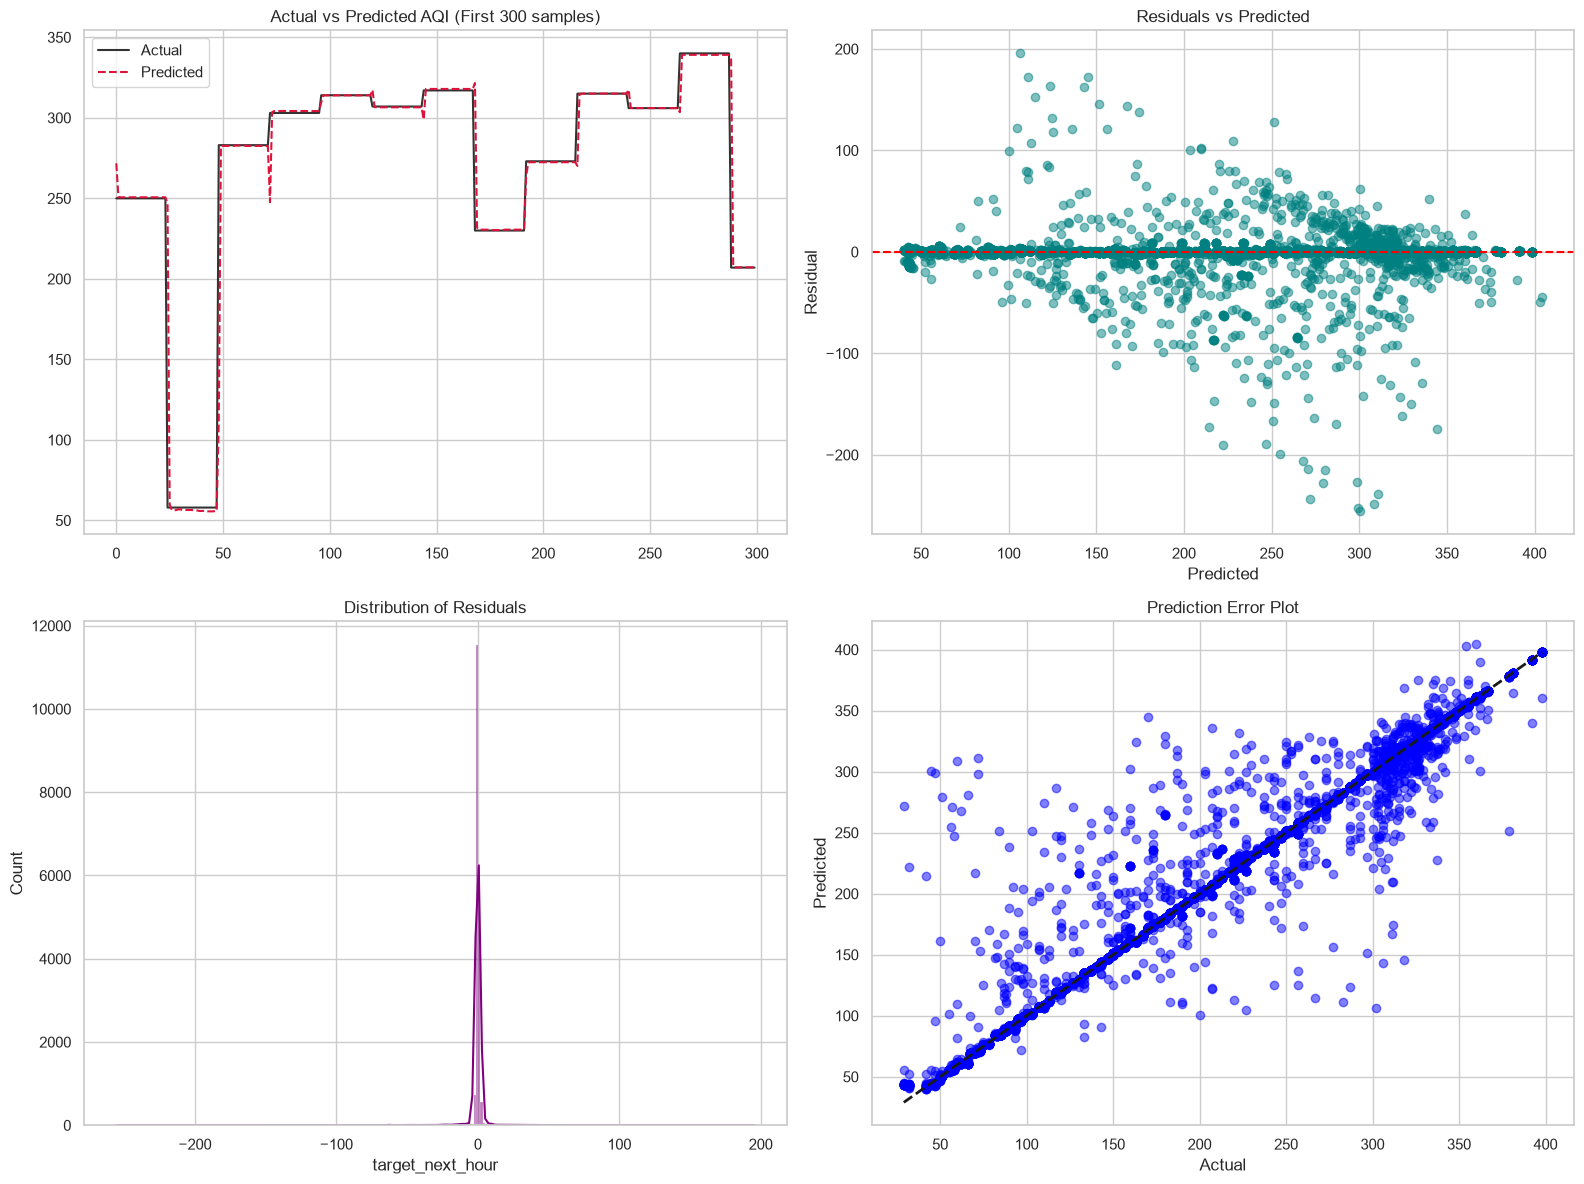

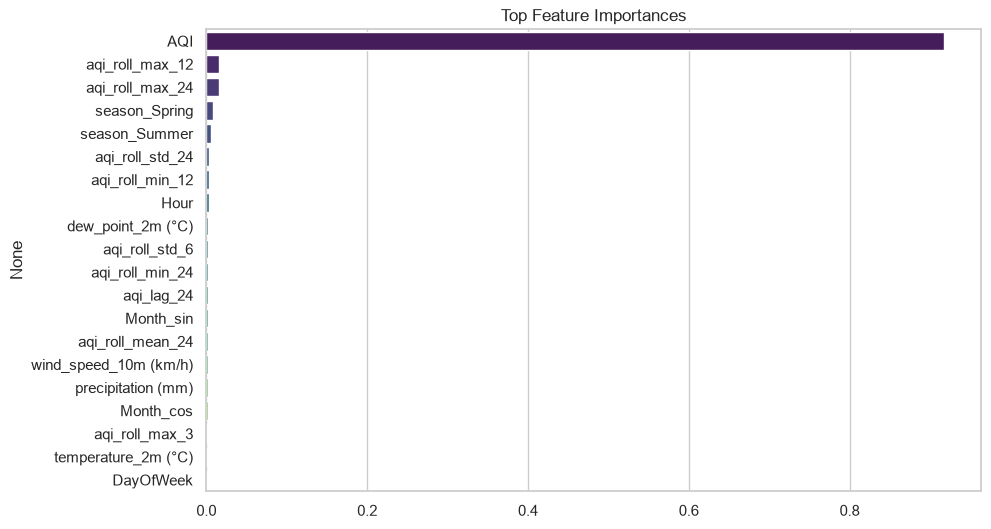

In [8]:
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted
axes[0, 0].plot(y_test.values[:300], label='Actual', color='black', alpha=0.8)
axes[0, 0].plot(y_pred_best[:300], label='Predicted', color='crimson', linestyle='--')
axes[0, 0].set_title('Actual vs Predicted AQI (First 300 samples)')
axes[0, 0].legend()

# 2. Residual Scatterplot
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.5, color='teal')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residual')

# 3. Residual Histogram
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Residuals')

# 4. Prediction Error
axes[1, 1].scatter(y_test, y_pred_best, alpha=0.5, color='blue')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1, 1].set_title('Prediction Error Plot')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# Feature Importance (Top 20)
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette='viridis')
    plt.title('Top Feature Importances')
    plt.show()

### Save Forecasting Model

In [9]:
models_dir = '../models/hourly' if os.path.exists('../models') else 'models/hourly'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(models_dir, 'model.pkl'))
joblib.dump(X_train.columns.tolist(), os.path.join(models_dir, 'feature_columns.pkl'))

metadata = {
    'best_model_name': best_name,
    'features': X_train.columns.tolist(),
    'training_parameters': str(best_model.get_params() if hasattr(best_model, 'get_params') else {}),
    'metrics': results[best_name],
    'cv_metrics': cv_results.get(best_name, {}),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'project_version': '1.1.0'
}

with open(os.path.join(models_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print('✓ Model and metadata successfully saved.')

✓ Model and metadata successfully saved.


### FastAPI Ready Functions

In [10]:
def forecast_next_hour(current_features):
    import joblib
    import pandas as pd
    model_p = 'models/hourly/model.pkl'
    if not os.path.exists(model_p):
        model_p = '../models/hourly/model.pkl'
    model = joblib.load(model_p)
    df = pd.DataFrame([current_features])
    return float(model.predict(df)[0])

def forecast_next_24_hours(current_features_dict):
    import joblib
    import pandas as pd
    import numpy as np
    
    model_p = 'models/hourly/model.pkl'
    scaler_p = 'models/hourly/scaler.pkl'
    if not os.path.exists(model_p):
        model_p = '../models/hourly/model.pkl'
        scaler_p = '../models/hourly/scaler.pkl'
        
    model = joblib.load(model_p)
    scaler = joblib.load(scaler_p)
    
    feature_names = scaler.feature_names_in_.tolist()
    
    def get_raw_value(scaled_val, name):
        idx = feature_names.index(name)
        return scaled_val * scaler.scale_[idx] + scaler.mean_[idx]
        
    def get_scaled_value(raw_val, name):
        idx = feature_names.index(name)
        return (raw_val - scaler.mean_[idx]) / scaler.scale_[idx]

    predictions = []
    features = current_features_dict.copy()
    
    current_aqi_raw = get_raw_value(features['AQI'], 'AQI')
    raw_history = [current_aqi_raw] * 24
    
    if 'aqi_lag_1' in features:
        raw_history[-2] = get_raw_value(features['aqi_lag_1'], 'aqi_lag_1')
    if 'aqi_lag_2' in features:
        raw_history[-3] = get_raw_value(features['aqi_lag_2'], 'aqi_lag_2')
    if 'aqi_lag_24' in features:
        raw_history[0] = get_raw_value(features['aqi_lag_24'], 'aqi_lag_24')

    current_hour = int(get_raw_value(features['Hour'], 'Hour'))
    current_month = int(get_raw_value(features['Month'], 'Month'))
    
    for h in range(1, 25):
        df_feats = pd.DataFrame([features])[feature_names]
        pred_aqi_raw = model.predict(df_feats)[0]
        pred_aqi_raw = max(0.0, pred_aqi_raw)
        
        predictions.append({
            'hour': h,
            'aqi': round(float(pred_aqi_raw), 2)
        })
        
        raw_history = raw_history[1:] + [pred_aqi_raw]
        features['AQI'] = get_scaled_value(pred_aqi_raw, 'AQI')
        features['aqi_lag_1'] = get_scaled_value(raw_history[-2], 'aqi_lag_1')
        features['aqi_lag_2'] = get_scaled_value(raw_history[-3], 'aqi_lag_2')
        features['aqi_lag_24'] = get_scaled_value(raw_history[0], 'aqi_lag_24')
        
        next_hour = (current_hour + h) % 24
        features['Hour'] = get_scaled_value(next_hour, 'Hour')
        features['Hour_sin'] = get_scaled_value(np.sin(2 * np.pi * next_hour / 24.0), 'Hour_sin')
        features['Hour_cos'] = get_scaled_value(np.cos(2 * np.pi * next_hour / 24.0), 'Hour_cos')
        
        for r in [3, 6, 12, 24]:
            roll_sub = raw_history[-r:]
            features[f'aqi_roll_mean_{r}'] = get_scaled_value(np.mean(roll_sub), f'aqi_roll_mean_{r}')
            features[f'aqi_roll_std_{r}'] = get_scaled_value(np.std(roll_sub) if len(roll_sub) > 1 else 0.0, f'aqi_roll_std_{r}')
            features[f'aqi_roll_min_{r}'] = get_scaled_value(np.min(roll_sub), f'aqi_roll_min_{r}')
            features[f'aqi_roll_max_{r}'] = get_scaled_value(np.max(roll_sub), f'aqi_roll_max_{r}')
            
        features['aqi_diff'] = get_scaled_value(raw_history[-1] - raw_history[-2], 'aqi_diff')
        features['aqi_pct_change'] = get_scaled_value((raw_history[-1] - raw_history[-2]) / max(raw_history[-2], 1.0), 'aqi_pct_change')
        
    return predictions

# Test recursive forecasting
test_sample = X_test.iloc[-1].to_dict()
print('Recursive 24h prediction output (first 3):', forecast_next_24_hours(test_sample)[:3])

Recursive 24h prediction output (first 3): [{'hour': 1, 'aqi': 193.12}, {'hour': 2, 'aqi': 205.89}, {'hour': 3, 'aqi': 202.92}]
